# Error Analysis

This notebook evaluates SquigNet over the held-out `data/test` split and
optionally under additional noise perturbations. We compute per-sample
accuracy and a confusion matrix over the four DNA bases.

In [9]:
from __future__ import annotations

import pickle
import sys
from pathlib import Path
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix

ROOT = Path("..").resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from architecture import SquigNet  # type: ignore
from config import BASE_TO_INT, INT_TO_BASE  # type: ignore
from inference import (  # type: ignore
    load_model,
    run_inference,
    greedy_decode,
    calculate_accuracy,
)

# Load test dataset
test_dir = ROOT / "data" / "test"
signals_path = test_dir / "signals.pt"
sequences_path = test_dir / "sequences.pkl"

signals: List[np.ndarray] = torch.load(signals_path, weights_only=False)
with open(sequences_path, "rb") as f:
    sequences: List[str] = pickle.load(f)

print(f"Loaded test dataset from {test_dir}")
print(f"  Num sequences: {len(sequences)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model(ROOT / "models" / "squig_model.pt", device=device)

Loaded test dataset from /Users/janetx/Desktop/Janet/Projects/SquigDecode/data/test
  Num sequences: 300


In [10]:
"""Evaluate accuracy over the test split without extra noise."""

accuracies: List[float] = []
all_targets: List[int] = []
all_preds: List[int] = []

for idx, (signal, target_seq) in enumerate(zip(signals, sequences), start=1):
    logits = run_inference(model, signal, device=device)
    pred_seq = greedy_decode(logits)
    acc = calculate_accuracy(pred_seq, target_seq)
    accuracies.append(acc)

    # Collect per-base labels for confusion matrix (skip blanks)
    for t_char, p_char in zip(target_seq, pred_seq):
        if t_char in BASE_TO_INT and p_char in BASE_TO_INT:
            all_targets.append(BASE_TO_INT[t_char])
            all_preds.append(BASE_TO_INT[p_char])

    if idx % 50 == 0 or idx == len(sequences):
        print(f"Processed {idx}/{len(sequences)} sequences; last accuracy={acc:.2%}")

mean_acc = float(np.mean(accuracies))
print(f"\nMean test accuracy (no extra noise): {mean_acc:.2%}")

Processed 50/300 sequences; last accuracy=97.96%
Processed 100/300 sequences; last accuracy=97.87%
Processed 150/300 sequences; last accuracy=96.55%
Processed 200/300 sequences; last accuracy=94.44%
Processed 250/300 sequences; last accuracy=96.49%
Processed 300/300 sequences; last accuracy=96.15%

Mean test accuracy (no extra noise): 95.93%


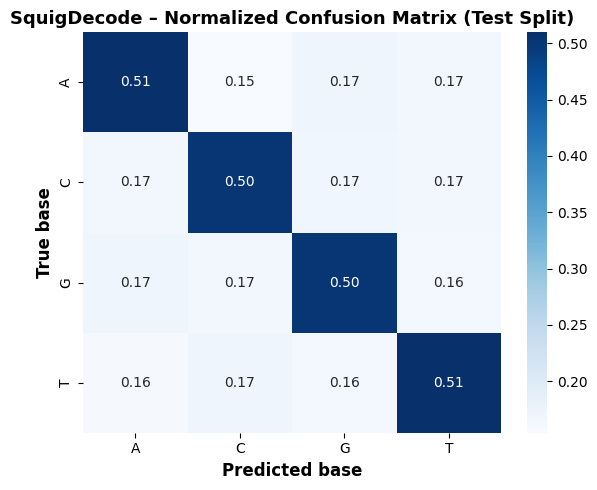

In [11]:
"""Plot confusion matrix over A/C/G/T bases."""

labels = [1, 2, 3, 4]
label_names = [INT_TO_BASE[i] for i in labels]

cm = confusion_matrix(all_targets, all_preds, labels=labels, normalize="true")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.xlabel("Predicted base", fontsize=12, fontweight="bold")
plt.ylabel("True base", fontsize=12, fontweight="bold")
plt.title(
    "SquigDecode – Normalized Confusion Matrix (Test Split)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

Extra noise σ=0.00: mean accuracy=95.93%
Extra noise σ=0.05: mean accuracy=95.83%
Extra noise σ=0.10: mean accuracy=95.63%
Extra noise σ=0.15: mean accuracy=95.06%
Extra noise σ=0.20: mean accuracy=93.36%
Extra noise σ=0.25: mean accuracy=90.69%
Extra noise σ=0.30: mean accuracy=84.88%
Extra noise σ=0.35: mean accuracy=75.66%
Extra noise σ=0.40: mean accuracy=64.94%
Extra noise σ=0.45: mean accuracy=55.81%
Extra noise σ=0.50: mean accuracy=46.60%


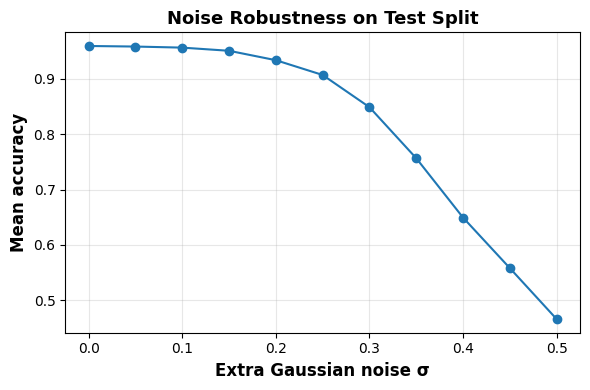

In [13]:
"""Optional: re-evaluate with additional Gaussian noise added to test signals."""


def evaluate_with_extra_noise(sigma: float) -> float:
    extra_accuracies: List[float] = []
    for signal, target_seq in zip(signals, sequences):
        noisy_signal = signal + np.random.normal(0.0, sigma, size=len(signal))
        logits = run_inference(model, noisy_signal, device=device)
        pred_seq = greedy_decode(logits)
        acc = calculate_accuracy(pred_seq, target_seq)
        extra_accuracies.append(acc)
    return float(np.mean(extra_accuracies))


sigmas = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
mean_accs = [evaluate_with_extra_noise(s) for s in sigmas]

for s, acc in zip(sigmas, mean_accs):
    print(f"Extra noise σ={s:.2f}: mean accuracy={acc:.2%}")

plt.figure(figsize=(6, 4))
plt.plot(sigmas, mean_accs, marker="o")
plt.xlabel("Extra Gaussian noise σ", fontsize=12, fontweight="bold")
plt.ylabel("Mean accuracy", fontsize=12, fontweight="bold")
plt.title("Noise Robustness on Test Split", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()